In [ ]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
print("Dataset downloaded successfully to:", path)

df = pd.read_csv(f"{path}/train.csv")
print(f"Dataset Shape: {df.shape[0]} records and {df.shape[1]} features.")

Using Colab cache for faster access to the 'airline-passenger-satisfaction' dataset.
Dataset downloaded successfully to: /kaggle/input/airline-passenger-satisfaction
Dataset Shape: 103904 records and 25 features.


In [ ]:
df.drop(['Unnamed: 0', 'id'], axis=1, inplace=True)
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print("Preprocessing complete. Sample of the encoded data:")
display(df.head())

Preprocessing complete. Sample of the encoded data:


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [ ]:
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after PCA reduction: {X_train_pca.shape[1]}")

Original number of features: 22
Number of features after PCA reduction: 17


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_pca, y_train)

rf_predictions = rf_model.predict(X_test_pca)
print("--- Random Forest Classifier Results ---")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, rf_predictions))

--- Random Forest Classifier Results ---
Accuracy: 93.07%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     11713
           1       0.94      0.89      0.92      9068

    accuracy                           0.93     20781
   macro avg       0.93      0.93      0.93     20781
weighted avg       0.93      0.93      0.93     20781



In [ ]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_pca, y_train)
lr_predictions = lr_model.predict(X_test_pca)

print("--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, lr_predictions) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, lr_predictions))

--- Logistic Regression Results ---
Accuracy: 87.52%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89     11713
           1       0.87      0.84      0.85      9068

    accuracy                           0.88     20781
   macro avg       0.87      0.87      0.87     20781
weighted avg       0.88      0.88      0.87     20781



/tmp/ipykernel_24627/3828178386.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='satisfaction', palette='viridis')


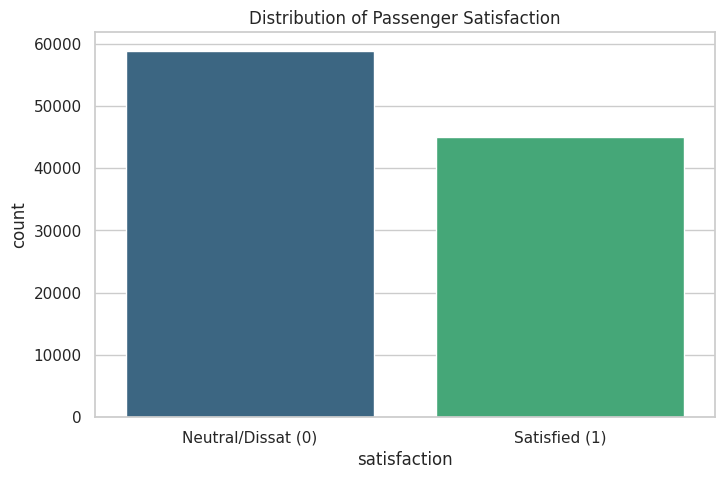

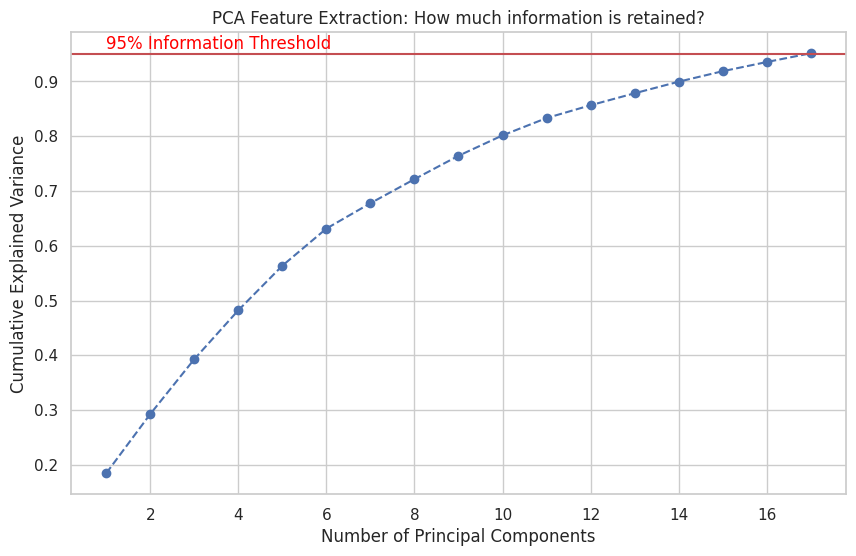

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
sns.countplot(data=df, x='satisfaction', palette='viridis')
plt.title('Distribution of Passenger Satisfaction')
plt.xticks(ticks=[0, 1], labels=['Neutral/Dissat (0)', 'Satisfied (1)'])
plt.show()

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')

plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(1, 0.96, '95% Information Threshold', color='red', fontsize=12)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Feature Extraction: How much information is retained?')
plt.grid(True)
plt.show()

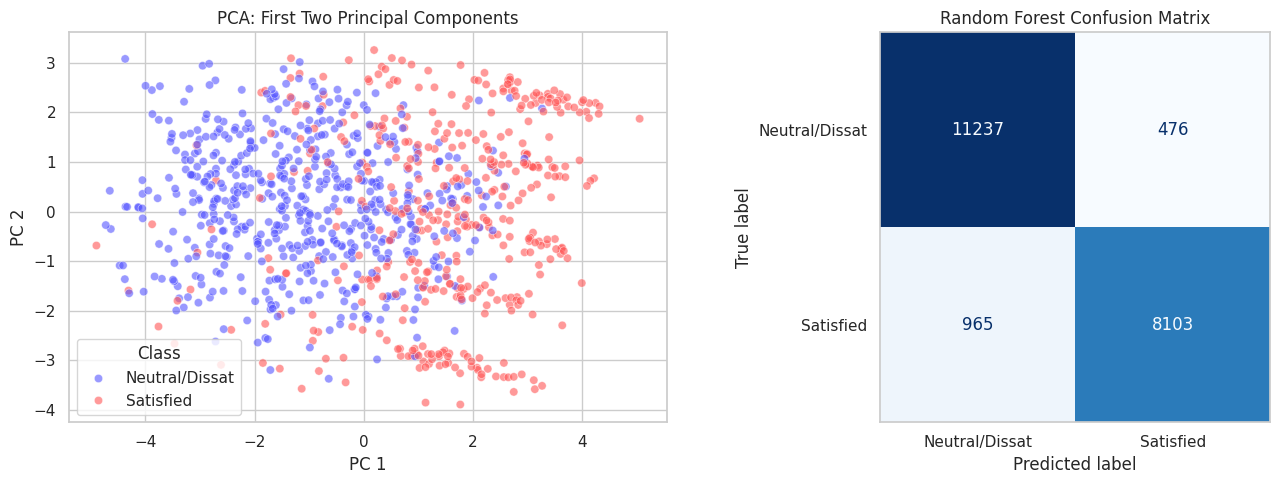

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=X_train_pca[:1000, 0], y=X_train_pca[:1000, 1], hue=y_train[:1000],
                palette='seismic', alpha=0.6, ax=axes[0])
axes[0].set(title='PCA: First Two Principal Components', xlabel='PC 1', ylabel='PC 2')
axes[0].legend(axes[0].get_legend_handles_labels()[0], ['Neutral/Dissat', 'Satisfied'], title='Class')

ConfusionMatrixDisplay.from_predictions(y_test, rf_predictions, display_labels=['Neutral/Dissat', 'Satisfied'],
                                        cmap='Blues', colorbar=False, ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].grid(False)

plt.tight_layout()
plt.show()

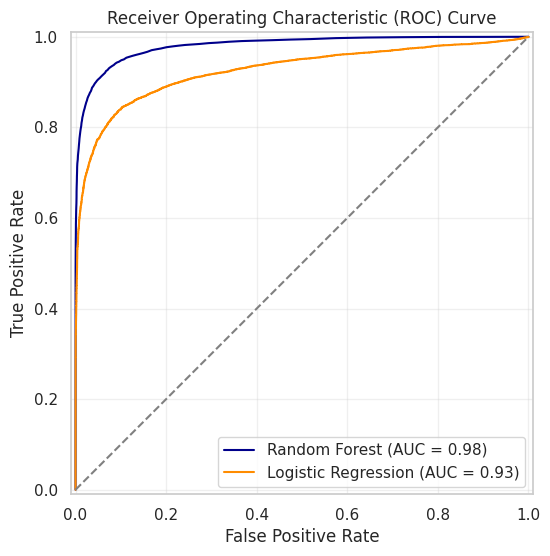

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(9, 6))

RocCurveDisplay.from_estimator(rf_model, X_test_pca, y_test, name='Random Forest', color='darkblue', ax=ax)
RocCurveDisplay.from_estimator(lr_model, X_test_pca, y_test, name='Logistic Regression', color='darkorange', ax=ax)

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
ax.set(title='Receiver Operating Characteristic (ROC) Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.grid(alpha=0.3)

plt.show()